In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

In [2]:
df = pd.read_csv(r"C:\Users\Pramita Mondal\PROJECTS DATA ANALYSIS\Marketing Funnel & Campaign Effectiveness Analysis for an E-Commerce Platform\ABTestingView.csv")

In [3]:
df.shape

(296315, 3)

In [10]:
from pandasql import sqldf

In [11]:
query = """
select 
     experiment_group,
     count(*) as users,
     sum(purchased) as purchasers
    from df
group by experiment_group;
"""
results = sqldf(query, locals())
print(results)

  EXPERIMENT_GROUP   users  purchasers
0          Control  100000        2164
1        Variant_A   98199         884
2        Variant_B   98116         905


In [12]:
data = pd.DataFrame({
      "group": ["Control","Variant_A","Variant_B"],
      "users": [100000,98199,98116],
      "purchasers": [2164,884,905]
})
data["Conversion_rate"] = data["purchasers"] /  data["users"]
data

,group,users,purchasers,Conversion_rate
0,Control,100000,2164,0.021640
1,Variant_A,98199,884,0.009002
2,Variant_B,98116,905,0.009224


Conversion Rate Comparison : The variants perform worse than control

In [4]:
import matplotlib.pyplot as plt

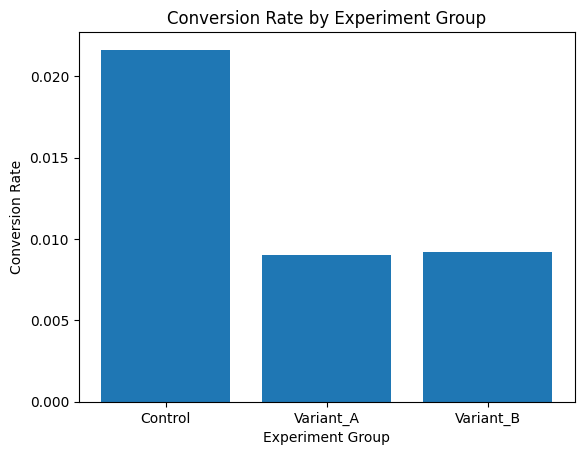

In [6]:
groups = ["Control","Variant_A","Variant_B"]
conversion_rates = [0.021640,0.009002,0.009224]

plt.figure()
plt.bar(groups,conversion_rates)
plt.title("Conversion Rate by Experiment Group")
plt.xlabel("Experiment Group")
plt.ylabel("Conversion Rate")
plt.show()

A/B Test: Control vs Variant_A

In [7]:
successes = np.array([2164,884])
samples = np.array([100000,98199])

In [14]:
z_stat, p_value = proportions_ztest (
    count = successes,
    nobs = samples,
    alternative = 'two-sided'
)
z_stat, p_value

(np.float64(22.860479274801285), np.float64(1.1496113695267516e-115))

Due to large sample size and high difference in conversion rates, the z score is extremely high,
large sample sizes reduce noise, which can lead to high Z scores

In [15]:
lw_1, uw_1 = proportion_confint(count = 2164, nobs= 100000, alpha=0.05)
lw_2, uw_2 = proportion_confint(count = 884, nobs= 98199, alpha=0.05)
print(f"Group 1: {lw_1:.4f} to {uw_1:.4f}")
print(f"Group 2: {lw_2:.4f} to {uw_2:.4f}")

Group 1: 0.0207 to 0.0225
Group 2: 0.0084 to 0.0096


The 95% confidence interval for control & variant donot overlap.
narrow confidence intervals reflect high precision due to large datasets

A/B Test: Control vs Variant_B

In [8]:
successes = np.array([2164,905])
samples = np.array([100000,98116])

In [17]:
z_stat, p_value = proportions_ztest (
    count = successes,
    nobs = samples,
    alternative = 'two-sided'
)
z_stat, p_value

(np.float64(22.374387343677498), np.float64(6.991148949260306e-111))

In [18]:
lw_1, uw_1 = proportion_confint(count = 2164, nobs= 100000, alpha=0.05)
lw_2, uw_2 = proportion_confint(count = 905, nobs= 98116, alpha=0.05)
print(f"Group 1: {lw_1:.4f} to {uw_1:.4f}")
print(f"Group 2: {lw_2:.4f} to {uw_2:.4f}")

Group 1: 0.0207 to 0.0225
Group 2: 0.0086 to 0.0098


Confidence intervals for each group are narrow and non-overlapping.

Uplift Analysis

In [9]:
control_rate = 2164/100000
variant_rate = 884/98199
uplift = (variant_rate-control_rate)/control_rate * 100
uplift

-58.400516029363516

Negative uplift signifies that variant underperforms the control

In [21]:
var_A = 0.009002
var_B = 0.009224
lift = (var_B - var_A) / var_A * 100
print(f"variant B provided a {lift:.2f}% lift over Variant A")

variant B provided a 2.47% lift over Variant A
